<a href="https://colab.research.google.com/github/Psyche-1/goit-ds-hw/blob/main/Hw9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
fashion_mnist = keras.datasets.fashion_mnist

In [4]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
X_test = X_test / 255.0

class_names = ["Футболка", "Штани", "Пуловер", "Сукня", "Пальто",
               "Сандалі", "Сорочка", "Кросівки", "Сумка", "Черевики"]

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train: (55000, 28, 28)
X_test: (10000, 28, 28)


In [11]:
print(f"Type X_train_full: {type(X_train_full)}")
print(f"Shape (X_train_full): {X_train_full.shape}")
print(f"Shape (y_train_full): {y_train_full.shape}")
print(f"Dtype (X_train_full): {X_train_full.dtype}")
print(f"Dtype (y_train_full): {y_train_full.dtype}")

nan_in_x = np.isnan(X_train_full).sum()
nan_in_y = np.isnan(y_train_full).sum()
print(f"NaN in X: {nan_in_x}")
print(f"NaN in y: {nan_in_y}")

print(f"Min: {X_train_full.min()}")
print(f"Max: {X_train_full.max()}")
print(f"Mean: {X_train_full.mean():.4f}")
print(f"Std: {X_train_full.std():.4f}")

classes, counts = np.unique(y_train_full, return_counts=True)
for cls, count in zip(classes, counts):
    print(f"Class {cls} ({class_names[cls]}): {count} images")

X_flat = X_train_full.reshape(X_train_full.shape[0], -1)
_, unique_indices = np.unique(X_flat, axis=0, return_index=True)
duplicate_count = len(X_train_full) - len(unique_indices)
print(f"Completely identical duplicate images found: {duplicate_count}")

Type X_train_full: <class 'numpy.ndarray'>
Shape (X_train_full): (60000, 28, 28)
Shape (y_train_full): (60000,)
Dtype (X_train_full): uint8
Dtype (y_train_full): uint8
NaN in X: 0
NaN in y: 0
Min: 0
Max: 255
Mean: 72.9404
Std: 90.0212
Class 0 (Футболка): 6000 images
Class 1 (Штани): 6000 images
Class 2 (Пуловер): 6000 images
Class 3 (Сукня): 6000 images
Class 4 (Пальто): 6000 images
Class 5 (Сандалі): 6000 images
Class 6 (Сорочка): 6000 images
Class 7 (Кросівки): 6000 images
Class 8 (Сумка): 6000 images
Class 9 (Черевики): 6000 images
Completely identical duplicate images found: 0


In [24]:
model_0 = keras.models.Sequential([
    layers.Flatten(input_shape=[28, 28]),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")
])

model_0.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

model_0.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [6]:
early_stopping_cb = keras.callbacks.EarlyStopping(patience=7, restore_best_weights=True, monitor="val_accuracy")

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, monitor="val_loss")

history = model_0.fit(X_train, y_train,
                    epochs=40,
                    batch_size=64,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])

Epoch 1/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.7995 - loss: 0.5642 - val_accuracy: 0.8126 - val_loss: 0.4935 - learning_rate: 0.0010
Epoch 2/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.8368 - loss: 0.4453 - val_accuracy: 0.8522 - val_loss: 0.4058 - learning_rate: 0.0010
Epoch 3/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8479 - loss: 0.4170 - val_accuracy: 0.8680 - val_loss: 0.3612 - learning_rate: 0.0010
Epoch 4/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - accuracy: 0.8526 - loss: 0.4018 - val_accuracy: 0.8754 - val_loss: 0.3349 - learning_rate: 0.0010
Epoch 5/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8583 - loss: 0.3865 - val_accuracy: 0.8622 - val_loss: 0.3748 - learning_rate: 0.0010
Epoch 6/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.8640 - loss: 0.3723 - val_accuracy: 0.8724 - val_loss: 0.3519 - learning_rate: 0.0010
Epoch 7/40
860/860 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8669 - l

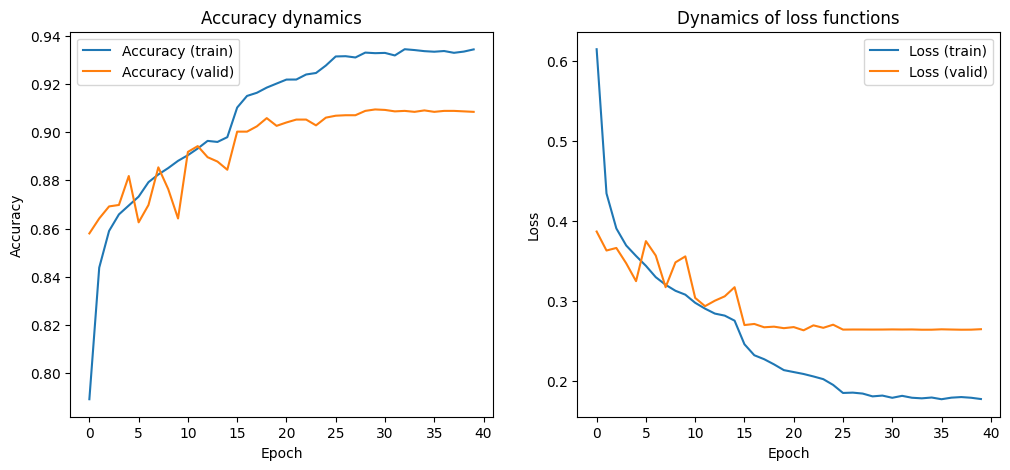

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [22]:
test_loss, test_accuracy = model_0.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

NameError: name 'model_0' is not defined

In [9]:
model_1 = keras.models.Sequential([
    layers.Flatten(input_shape=[28, 28]),

    layers.Dense(1024, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(10, activation="softmax")
])

model_1.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.0005),
              metrics=["accuracy"])

model_1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,834 (5.73 MB)

 Trainable params: 1,497,994 (5.71 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [10]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.2,
    patience=3,
    monitor="val_loss"
)

history = model_1.fit(X_train, y_train,
                    epochs=50,
                    batch_size=128,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])

Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.7893 - loss: 0.6145 - val_accuracy: 0.8580 - val_loss: 0.3867 - learning_rate: 5.0000e-04
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 46ms/step - accuracy: 0.8438 - loss: 0.4343 - val_accuracy: 0.8642 - val_loss: 0.3630 - learning_rate: 5.0000e-04
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8590 - loss: 0.3906 - val_accuracy: 0.8692 - val_loss: 0.3662 - learning_rate: 5.0000e-04
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8659 - loss: 0.3693 - val_accuracy: 0.8698 - val_loss: 0.3470 - learning_rate: 5.0000e-04
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/step - accuracy: 0.8696 - loss: 0.3562 - val_accuracy: 0.8818 - val_loss: 0.3247 - learning_rate: 5.0000e-04
Epoch 6/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8733 - loss: 0.3439 - val_accuracy: 0.8626 - val_loss: 0.3747 - learning_rate: 5.0000e-04
Epoch 7/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 19s 45ms/ste

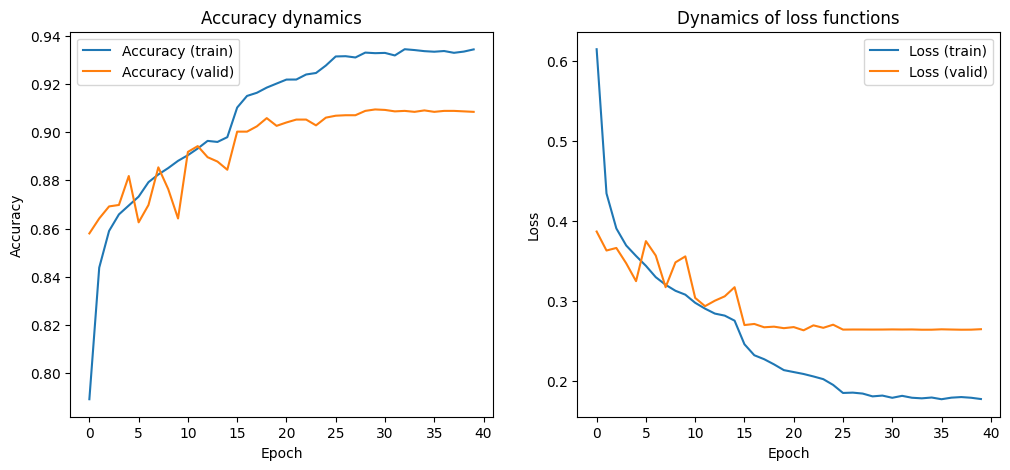

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [44]:
test_loss, test_accuracy = model_1.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 90%
Test loss: 0.2937


In [17]:
model_2 = keras.models.Sequential([
    layers.Flatten(input_shape=[28, 28]),

    layers.Dense(1024, activation="selu", kernel_initializer="lecun_normal"),
    layers.AlphaDropout(0.2),

    layers.Dense(512, activation="selu", kernel_initializer="lecun_normal"),
    layers.AlphaDropout(0.2),

    layers.Dense(256, activation="selu", kernel_initializer="lecun_normal"),
    layers.AlphaDropout(0.2),

    layers.Dense(128, activation="selu", kernel_initializer="lecun_normal"),
    layers.AlphaDropout(0.1),

    layers.Dense(10, activation="softmax")
])

model_2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Nadam(learning_rate=0.0005),
              metrics=["accuracy"])

model_2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ alpha_dropout (AlphaDropout)    │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ alpha_dropout_1 (AlphaDropout)  │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ alpha_dropout_2 (AlphaDropout)  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ alpha_dropout_3 (AlphaDropout)  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,494,154 (5.70 MB)

 Trainable params: 1,494,154 (5.70 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=12,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.3,
    patience=4,
    monitor="val_loss"
)

history = model_2.fit(X_train, y_train,
                    epochs=60,
                    batch_size=128,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])


Epoch 1/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 27s 56ms/step - accuracy: 0.7406 - loss: 0.7093 - val_accuracy: 0.8240 - val_loss: 0.6465 - learning_rate: 5.0000e-04
Epoch 2/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8260 - loss: 0.4777 - val_accuracy: 0.8496 - val_loss: 0.5684 - learning_rate: 5.0000e-04
Epoch 3/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8423 - loss: 0.4311 - val_accuracy: 0.8572 - val_loss: 0.5539 - learning_rate: 5.0000e-04
Epoch 4/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8539 - loss: 0.4038 - val_accuracy: 0.8576 - val_loss: 0.5439 - learning_rate: 5.0000e-04
Epoch 5/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 28s 65ms/step - accuracy: 0.8574 - loss: 0.3879 - val_accuracy: 0.8722 - val_loss: 0.4898 - learning_rate: 5.0000e-04
Epoch 6/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.8643 - loss: 0.3689 - val_accuracy: 0.8714 - val_loss: 0.4812 - learning_rate: 5.0000e-04
Epoch 7/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/ste

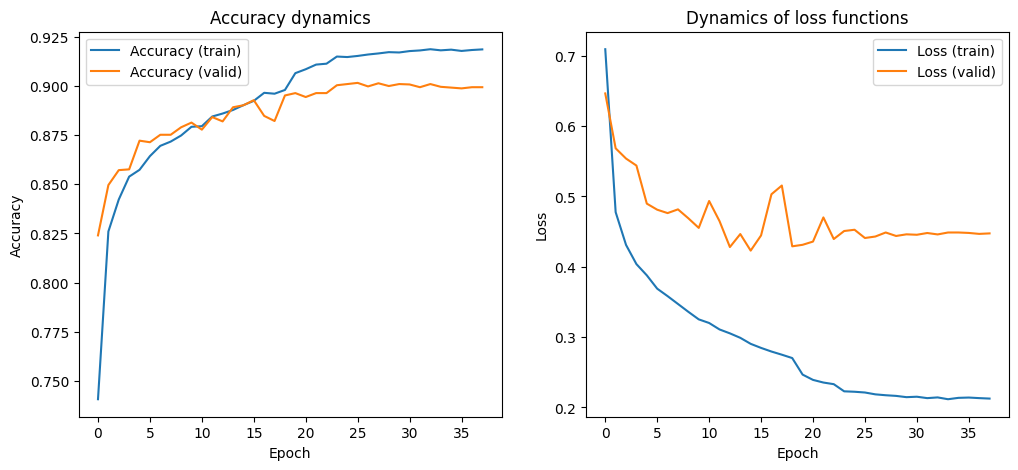

In [19]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [45]:
test_loss, test_accuracy = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 89%
Test loss: 0.5024


In [25]:
model_3 = keras.models.Sequential([
    layers.Flatten(input_shape=[28, 28]),

    layers.Dense(1024, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.15),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")
])

model_3.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

model_3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,834 (5.73 MB)

 Trainable params: 1,497,994 (5.71 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [26]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=8,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=3,
    monitor="val_loss"
)

history = model_3.fit(X_train, y_train,
                    epochs=50,
                    batch_size=128,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])


Epoch 1/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.8130 - loss: 0.5268 - val_accuracy: 0.8604 - val_loss: 0.3947 - learning_rate: 0.0010
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - accuracy: 0.8494 - loss: 0.4077 - val_accuracy: 0.8504 - val_loss: 0.4188 - learning_rate: 0.0010
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.8641 - loss: 0.3768 - val_accuracy: 0.8354 - val_loss: 0.4670 - learning_rate: 0.0010
Epoch 4/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.8678 - loss: 0.3598 - val_accuracy: 0.8716 - val_loss: 0.3493 - learning_rate: 0.0010
Epoch 5/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 20s 47ms/step - accuracy: 0.8755 - loss: 0.3376 - val_accuracy: 0.8702 - val_loss: 0.3506 - learning_rate: 0.0010
Epoch 6/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.8781 - loss: 0.3286 - val_accuracy: 0.8734 - val_loss: 0.3657 - learning_rate: 0.0010
Epoch 7/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8825 - l

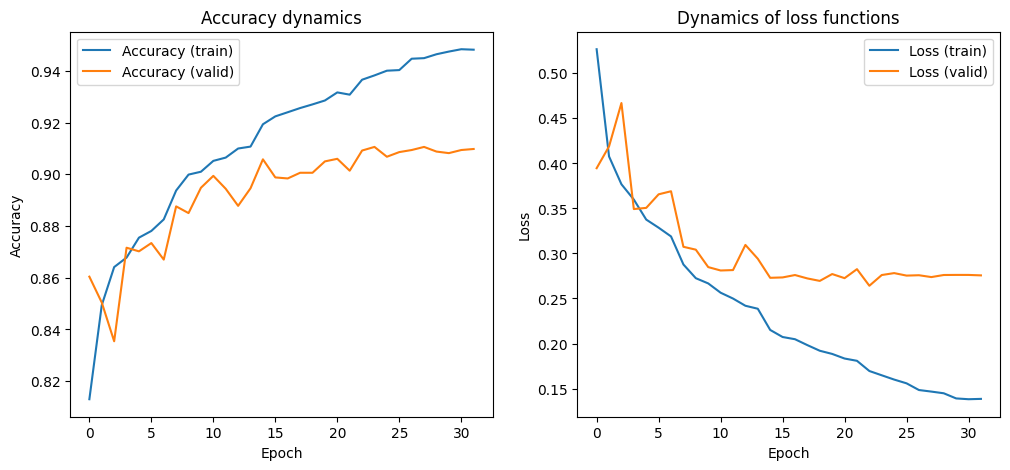

In [27]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [46]:
test_loss, test_accuracy = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 90%
Test loss: 0.3069


In [30]:
data_augmentation = keras.Sequential([
    layers.RandomTranslation(height_factor=0.05, width_factor=0.05, fill_mode="constant"),
    layers.RandomFlip("horizontal"),
])

model_4 = keras.models.Sequential([
    layers.Input(shape=(28, 28, 1)),

    data_augmentation,

    layers.Flatten(),

    layers.Dense(1024, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(512, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(10, activation="softmax")
])

model_4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.Adam(learning_rate=0.001),
              metrics=["accuracy"])

model_4.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_7 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,834 (5.73 MB)

 Trainable params: 1,497,994 (5.71 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [31]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=12,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=4,
    monitor="val_loss"
)

history = model_4.fit(X_train, y_train,
                    epochs=60,
                    batch_size=128,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])


Epoch 1/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.7590 - loss: 0.6634 - val_accuracy: 0.8386 - val_loss: 0.4365 - learning_rate: 0.0010
Epoch 2/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8111 - loss: 0.5193 - val_accuracy: 0.8466 - val_loss: 0.4280 - learning_rate: 0.0010
Epoch 3/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - accuracy: 0.8211 - loss: 0.4888 - val_accuracy: 0.8470 - val_loss: 0.4217 - learning_rate: 0.0010
Epoch 4/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.8262 - loss: 0.4687 - val_accuracy: 0.8444 - val_loss: 0.3971 - learning_rate: 0.0010
Epoch 5/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.8338 - loss: 0.4532 - val_accuracy: 0.8502 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 6/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.8353 - loss: 0.4425 - val_accuracy: 0.8556 - val_loss: 0.3818 - learning_rate: 0.0010
Epoch 7/60
430/430 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.8399 - l

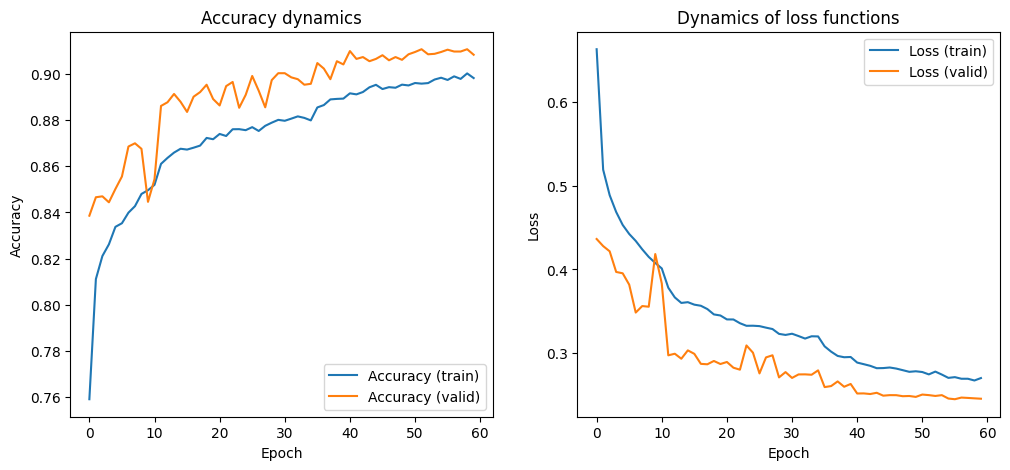

In [32]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [38]:
test_loss, test_accuracy = model_4.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 89.60%
Test loss: 0.2847


In [34]:
model_5 = keras.models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),

    layers.Dense(1024, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(512, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(10, activation="softmax")
])

model_5.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
              metrics=["accuracy"])

model_5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,834 (5.73 MB)

 Trainable params: 1,497,994 (5.71 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [35]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=4,
    monitor="val_loss"
)

history = model_5.fit(X_train, y_train,
                    epochs=60,
                    batch_size=64,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])

Epoch 1/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 36s 37ms/step - accuracy: 0.8198 - loss: 0.5016 - val_accuracy: 0.8592 - val_loss: 0.3792 - learning_rate: 0.0010
Epoch 2/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.8563 - loss: 0.3918 - val_accuracy: 0.8740 - val_loss: 0.3503 - learning_rate: 0.0010
Epoch 3/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.8686 - loss: 0.3577 - val_accuracy: 0.8672 - val_loss: 0.3524 - learning_rate: 0.0010
Epoch 4/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step - accuracy: 0.8741 - loss: 0.3400 - val_accuracy: 0.8716 - val_loss: 0.3477 - learning_rate: 0.0010
Epoch 5/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.8810 - loss: 0.3210 - val_accuracy: 0.8836 - val_loss: 0.3224 - learning_rate: 0.0010
Epoch 6/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 42s 40ms/step - accuracy: 0.8849 - loss: 0.3095 - val_accuracy: 0.8828 - val_loss: 0.3338 - learning_rate: 0.0010
Epoch 7/60
860/860 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.8902 - l

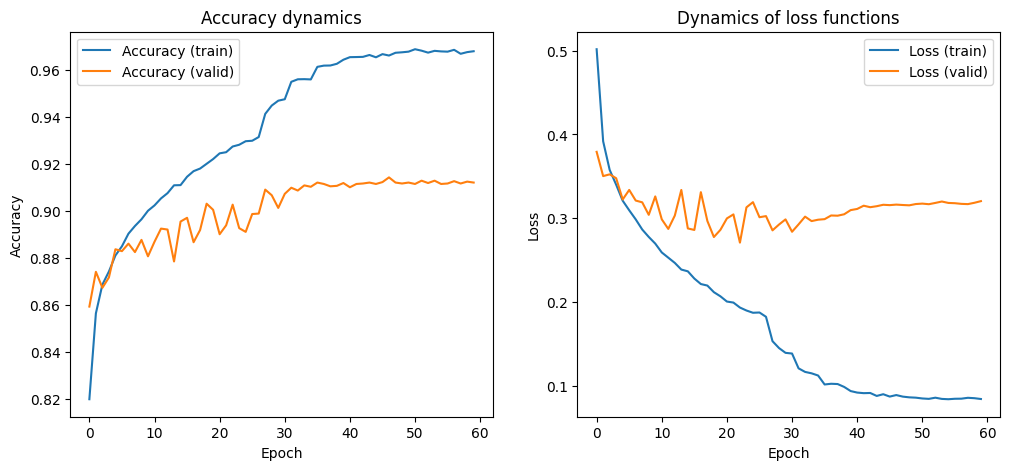

In [36]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [43]:
test_loss, test_accuracy = model_5.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 91%
Test loss: 0.3503


In [5]:
def create_model():
    model = keras.models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),

        layers.Dense(1024, activation="swish"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(512, activation="swish"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(256, activation="swish"),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(128, activation="swish"),
        layers.BatchNormalization(),
        layers.Dropout(0.1),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
                  metrics=["accuracy"])
    return model


In [6]:
num_models = 3
ensemble_models = []

early_stopping_cb = keras.callbacks.EarlyStopping(patience=12, restore_best_weights=True, monitor="val_accuracy")
lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor="val_loss")

for i in range(num_models):
    print(f"\n№{i+1} from {num_models}")
    model = create_model()

    history = model.fit(X_train, y_train,
                        epochs=45,
                        batch_size=64,
                        validation_data=(X_valid, y_valid),
                        callbacks=[early_stopping_cb, lr_scheduler_cb],
                        verbose=1)

    ensemble_models.append(model)



№1 from 3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.8195 - loss: 0.5013 - val_accuracy: 0.8496 - val_loss: 0.4102 - learning_rate: 0.0010
Epoch 2/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8560 - loss: 0.3913 - val_accuracy: 0.8744 - val_loss: 0.3597 - learning_rate: 0.0010
Epoch 3/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8697 - loss: 0.3548 - val_accuracy: 0.8450 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 4/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8749 - loss: 0.3363 - val_accuracy: 0.8790 - val_loss: 0.3206 - learning_rate: 0.0010
Epoch 5/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8811 - loss: 0.3250 - val_accuracy: 0.8754 - val_loss: 0.3550 - learning_rate: 0.0010
Epoch 6/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8859 - loss: 0.3074 - val_accuracy: 0.8754 - val_loss: 0.3408 - learning_rate: 0.0010
Epoch 7/45
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8894 - loss: 0.2974 

In [8]:
test_predictions = [model.predict(X_test, verbose=0) for model in ensemble_models]

avg_predictions = np.mean(test_predictions, axis=0)

final_preds = np.argmax(avg_predictions, axis=1)

ensemble_accuracy = np.mean(final_preds == y_test)

print(f"Ensemble accuracy: {ensemble_accuracy * 100:.0f}%")


Ensemble accuracy: 89%


In [9]:
model_6 = keras.models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),

    layers.Dense(1024, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(512, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(10, activation="softmax")
])

model_6.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
              metrics=["accuracy"])

model_6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,834 (5.73 MB)

 Trainable params: 1,497,994 (5.71 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [10]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=4,
    monitor="val_loss"
)

history = model_6.fit(X_train, y_train,
                    epochs=60,
                    batch_size=256,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])

Epoch 1/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - accuracy: 0.8238 - loss: 0.4980 - val_accuracy: 0.8058 - val_loss: 0.5185 - learning_rate: 0.0010
Epoch 2/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8649 - loss: 0.3652 - val_accuracy: 0.8762 - val_loss: 0.3368 - learning_rate: 0.0010
Epoch 3/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8804 - loss: 0.3265 - val_accuracy: 0.8674 - val_loss: 0.3559 - learning_rate: 0.0010
Epoch 4/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8862 - loss: 0.3037 - val_accuracy: 0.8808 - val_loss: 0.3192 - learning_rate: 0.0010
Epoch 5/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8939 - loss: 0.2837 - val_accuracy: 0.8618 - val_loss: 0.3908 - learning_rate: 0.0010
Epoch 6/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9010 - loss: 0.2678 - val_accuracy: 0.8796 - val_loss: 0.3343 - learning_rate: 0.0010
Epoch 7/60
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9038 - loss: 0.2578 

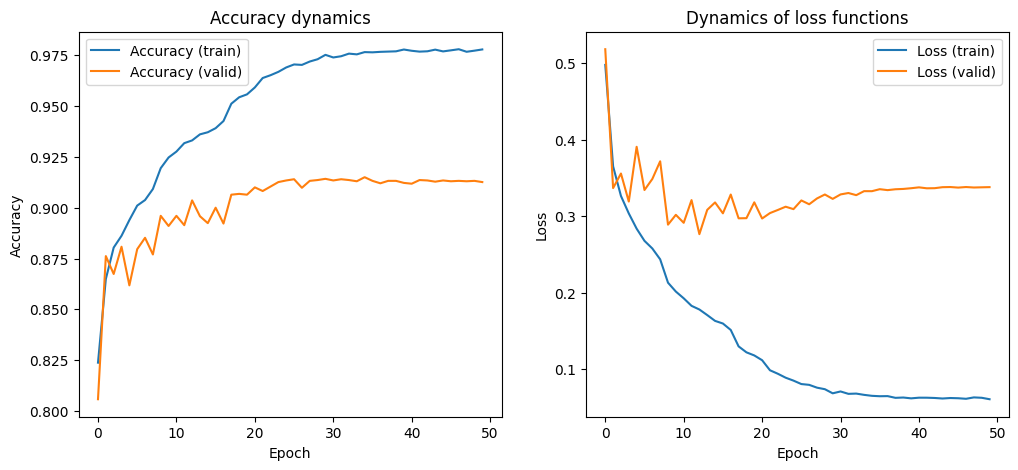

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [14]:
test_loss, test_accuracy = model_6.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 91%
Test loss: 0.3678


In [15]:
model_7 = keras.models.Sequential([
    layers.Flatten(input_shape=(28, 28, 1)),

    layers.Dense(1024, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(512, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(256, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.2),

    layers.Dense(128, activation="swish"),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(10, activation="softmax")
])

model_7.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4),
              metrics=["accuracy"])

model_7.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,501,834 (5.73 MB)

 Trainable params: 1,497,994 (5.71 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [16]:
early_stopping_cb = keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True,
    monitor="val_accuracy"
)

lr_scheduler_cb = keras.callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=4,
    monitor="val_loss"
)

history = model_7.fit(X_train, y_train,
                    epochs=60,
                    batch_size=1024,
                    validation_data=(X_valid, y_valid),
                    callbacks=[early_stopping_cb, lr_scheduler_cb])

Epoch 1/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 136ms/step - accuracy: 0.7963 - loss: 0.5864 - val_accuracy: 0.7228 - val_loss: 1.1120 - learning_rate: 0.0010
Epoch 2/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8601 - loss: 0.3836 - val_accuracy: 0.7654 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 3/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8762 - loss: 0.3369 - val_accuracy: 0.7828 - val_loss: 0.6990 - learning_rate: 0.0010
Epoch 4/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8830 - loss: 0.3158 - val_accuracy: 0.8186 - val_loss: 0.5420 - learning_rate: 0.0010
Epoch 5/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8923 - loss: 0.2909 - val_accuracy: 0.8284 - val_loss: 0.4696 - learning_rate: 0.0010
Epoch 6/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8968 - loss: 0.2752 - val_accuracy: 0.8658 - val_loss: 0.3560 - learning_rate: 0.0010
Epoch 7/60
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9013 - loss: 0.2631 - val_accurac

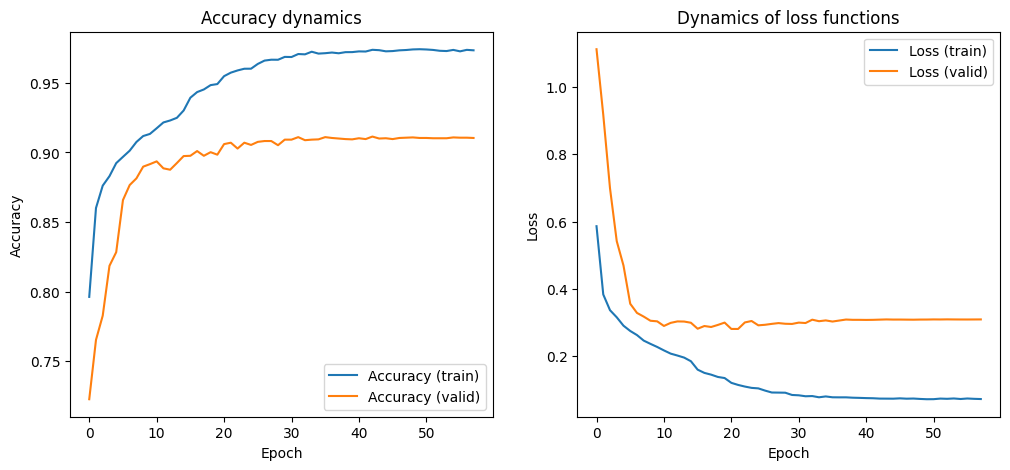

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Accuracy (train)')
plt.plot(history.history['val_accuracy'], label='Accuracy (valid)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy dynamics')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (valid)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dynamics of loss functions')

plt.show()

In [20]:
test_loss, test_accuracy = model_7.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_accuracy * 100:.0f}%")
print(f"Test loss: {test_loss:.4f}")

Test accuracy: 91%
Test loss: 0.3435
